In [4]:
# !pip install pandas
# !pip install matplotlib seaborn numpy

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [51]:
# Set style
sns.set(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

dpi = 150  # figure resolution
output_dir = "./figures"  # save directory
figsize=(9, 5)

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

In [52]:
# Dataset sizes in GB
DATA_SIZES = {
    "small_1": 3.9,
    "small_2": 7.8,
    "small_4": 15.7,
    "small_6": 23.4,
    "small_8": 31.0,
    "small_16": 62.2
}

In [53]:
# Load the data
df = pd.read_csv("../data/data.csv")
df.head(5)
df =df.drop("AppID",axis=1)
df['DatasetSizeGB'] = df['Data'].apply(lambda x: DATA_SIZES[x])
df = df.drop_duplicates()

In [54]:
# Columns in milliseconds
ms_cols = [
    "AppTimeMs",
    "ExecRunTimeMs",
    "GCMs",
    "ShuffleReadMs",
    "ShuffleWriteMs",
    "CommMs",
    "ComputeMs"
]

# Convert ms -> seconds
for col in ms_cols:
    df[col.replace("Ms", "Sec")] = df[col] / 1000


# Columns in MB
mb_cols = [
    "MemSpillMB",
    "DiskSpillMB",
    "PeakHeapMB"
]

# Convert MB -> GB
for col in mb_cols:
    df[col.replace("MB", "GB")] = df[col] / 1024

df.head()

,Type,Execs,Cores,TotalCores,MemGB,Data,S1,S2,S3,S4,...,AppTimeSec,ExecRunTimeSec,GCSec,ShuffleReadSec,ShuffleWriteSec,CommSec,ComputeSec,MemSpillGB,DiskSpillGB,PeakHeapGB
0,Strong,2,4,8,8,small_2,83.275715,18.037021,173.352211,155.737509,...,996.625,6669.186,127.693,24.759,7.967341,32.726341,6508.766659,4.0,1.217508,2.775100
1,Strong,2,4,8,8,small_2,79.278612,18.818305,176.119899,162.635966,...,1017.335,6654.556,128.990,24.782,7.119986,31.901986,6493.664014,4.0,1.217508,2.874320
2,Strong,2,4,8,8,small_2,83.471000,17.936557,174.220089,162.296951,...,1013.019,6826.213,127.649,31.584,7.079945,38.663945,6659.900055,4.0,1.217508,2.892908
3,Strong,4,4,16,8,small_2,86.075155,17.719478,120.552096,106.170557,...,748.731,7390.679,130.758,110.457,7.676113,118.133113,7141.787887,4.0,1.217508,1.653612
4,Strong,4,4,16,8,small_2,93.292741,25.678370,166.839224,91.648111,...,737.264,7487.046,140.135,122.300,7.694418,129.994418,7216.916582,4.0,1.217508,1.921171


In [55]:
# Calculate derived metrics
df['TimePerCore'] = df['AppTimeSec'] / df['TotalCores']
# --- Time per Unit Data ---
df['SizeFactor'] = df['Data'].str.extract(r'_(\d+)').astype(float)
df['TimePerUnit'] = df['AppTimeSec'] / df['SizeFactor']

# Split data by scaling type
strong_df = df[df['Type'] == 'Strong'].copy()
weak_df = df[df['Type'] == 'Weak'].copy()

# Calculate additional metrics for strong scaling
strong_df['Speedup'] = strong_df.groupby('Data')['AppTimeMs'].transform(
    lambda x: x.iloc[0] / x
)
strong_df['Efficiency'] = (strong_df['Speedup'] / 
                           (strong_df['TotalCores'] / strong_df['TotalCores'].min())) * 100

# Derived metrics for strong scaling
strong_df['GCRatio'] = 100 * strong_df['GCSec'] / strong_df['ExecRunTimeSec']
strong_df['ComputeRatio'] = 100 * strong_df['ComputeSec'] / strong_df['ExecRunTimeSec']
strong_df['CommRatio'] = 100 * strong_df['CommSec'] / strong_df['ExecRunTimeSec']

cores = strong_df['TotalCores'].unique()
cores.sort()

### 1. STRONG SCALING TABLES

#### TABLE 1: Strong Scaling Performance Summary

In [56]:
strong_perf_table = strong_df.groupby('TotalCores').agg({
    'AppTimeSec': 'mean',
    'Speedup': 'mean',
    'Efficiency': 'mean',
    'Parallelism': 'mean'
}).round(2)

strong_perf_table['IdealSpeedup'] = strong_perf_table.index / strong_perf_table.index.min()
strong_perf_table['Utilization%'] = (strong_perf_table['Parallelism'] / strong_perf_table.index * 100).round(1)

strong_perf_table = strong_perf_table.reset_index()
strong_perf_table = strong_perf_table[['TotalCores', 'AppTimeSec', 'Speedup', 'IdealSpeedup', 
                                        'Efficiency', 'Parallelism', 'Utilization%']]

print("="*80)
print("TABLE 1: Strong Scaling Performance Summary")
print("Shows core metrics for strong scaling analysis including speedup, efficiency, and parallelism utilization.")
print("="*80)
print(strong_perf_table.to_string(index=False))


TABLE 1: Strong Scaling Performance Summary
Shows core metrics for strong scaling analysis including speedup, efficiency, and parallelism utilization.
 TotalCores  AppTimeSec  Speedup  IdealSpeedup  Efficiency  Parallelism  Utilization%
          8     1008.99     0.99           1.0       98.78         6.66          83.2
         16      784.12     1.28           2.0       63.89         9.73          60.8
         32      518.62     1.92           4.0       48.05        15.22          47.6
         64      335.92     2.97           8.0       37.17        28.41          44.4
        128      340.78     2.93          16.0       18.29        30.81          24.1


####  TABLE 2: Strong Scaling Time Breakdown

In [57]:
strong_time_table = strong_df.groupby('TotalCores').agg({
    'AppTimeSec': 'mean',
    'ComputeSec': 'mean',
    'GCSec': 'mean',
    'ShuffleReadSec': 'mean',
    'ShuffleWriteSec': 'mean',
    'ComputeRatio': 'mean',
    'GCRatio': 'mean',
    'CommRatio': 'mean'
}).round(2)

strong_time_table = strong_time_table.reset_index()
strong_time_table = strong_time_table[['TotalCores', 'AppTimeSec', 'ComputeSec', 'GCSec', 
                                        'ShuffleReadSec', 'ShuffleWriteSec', 
                                        'ComputeRatio', 'GCRatio', 'CommRatio']]

print("="*80)
print("TABLE 2: Strong Scaling Time Breakdown")
print("Strong Scaling Time Breakdown - Breaks down where time is spent (compute, GC, shuffle) to identify bottlenecks.")
print("="*80)
print(strong_time_table.to_string(index=False))

TABLE 2: Strong Scaling Time Breakdown
Strong Scaling Time Breakdown - Breaks down where time is spent (compute, GC, shuffle) to identify bottlenecks.
 TotalCores  AppTimeSec  ComputeSec  GCSec  ShuffleReadSec  ShuffleWriteSec  ComputeRatio  GCRatio  CommRatio
          8     1008.99     6554.11 128.11           27.04             7.39         97.58     1.91       0.51
         16      784.12     7341.08 140.77          117.27             8.14         96.50     1.85       1.65
         32      518.62     7391.24 163.45          326.10            10.17         93.67     2.07       4.26
         64      335.92     8622.96 228.95          667.78            15.25         90.43     2.40       7.17
        128      340.78     9319.99 269.18          879.36            17.27         88.87     2.56       8.56


### 1. STRONG SCALING PLOTS

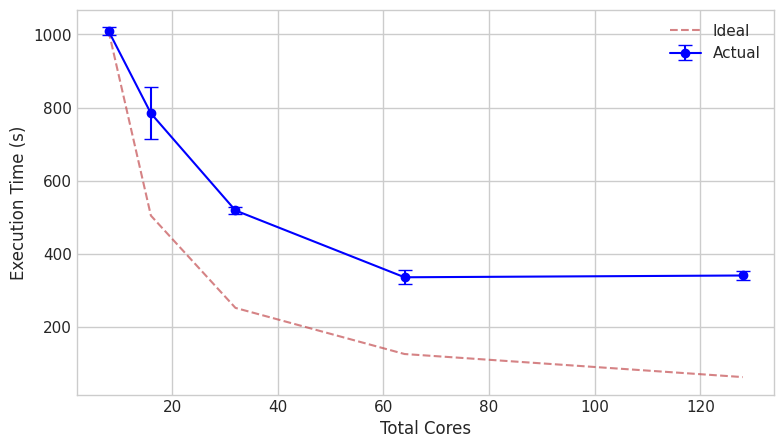

In [58]:
# ----- Plot 1: Execution Time -----
plt.figure(figsize=figsize)
times = strong_df.groupby('TotalCores')['AppTimeSec'].mean()
time_std = strong_df.groupby('TotalCores')['AppTimeSec'].std()
baseline_time = times.loc[cores[0]]
ideal_time = baseline_time * (cores[0] / cores)

plt.errorbar(cores, times, yerr=time_std, fmt='o-', capsize=5, color='blue', label='Actual')
plt.plot(cores, ideal_time, 'r--', label='Ideal', alpha=0.7)
plt.xlabel('Total Cores')
plt.ylabel('Execution Time (s)')
# plt.title('Strong Scaling: Execution Time')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/strong_execution_time.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

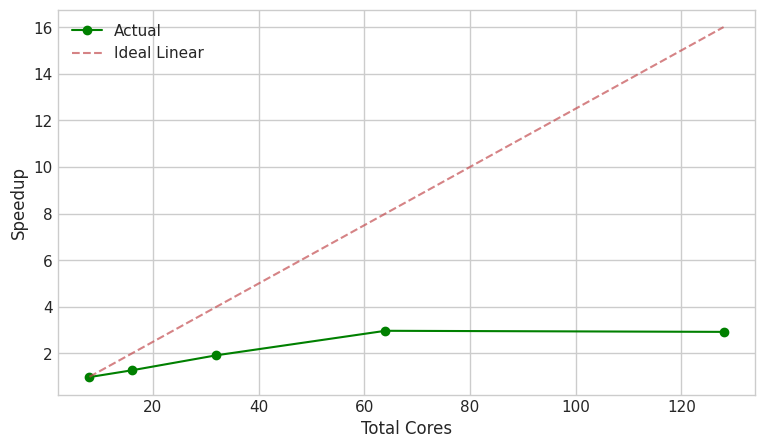

In [59]:
# ----- Plot 2: Speedup -----
plt.figure(figsize=figsize)
plt.plot(cores, strong_df.groupby('TotalCores')['Speedup'].mean(), 'o-', color='green', label='Actual')
plt.plot(cores, cores/cores[0], 'r--', label='Ideal Linear', alpha=0.7)
plt.xlabel('Total Cores')
plt.ylabel('Speedup')
# plt.title('Strong Scaling: Speedup')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/strong_speedup.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

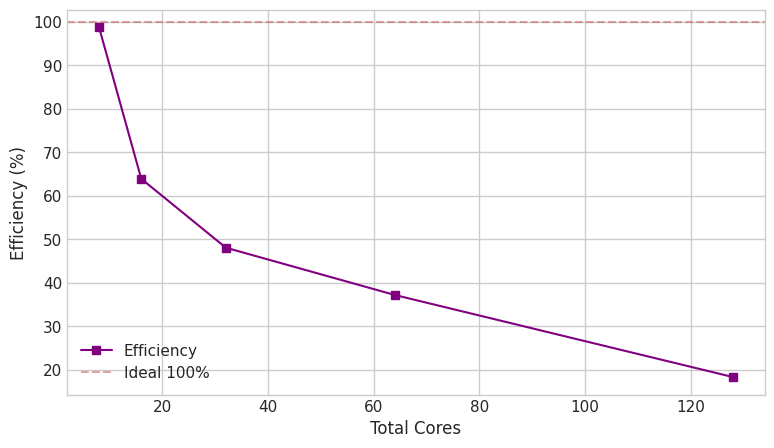

In [60]:
# ----- Plot 3: Efficiency -----
plt.figure(figsize=figsize)
plt.plot(cores, strong_df.groupby('TotalCores')['Efficiency'].mean(), 's-', color='purple', label='Efficiency')
plt.axhline(100, color='r', linestyle='--', alpha=0.5, label='Ideal 100%')
plt.xlabel('Total Cores')
plt.ylabel('Efficiency (%)')
# plt.title('Strong Scaling: Parallel Efficiency')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/strong_efficiency.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 900x500 with 0 Axes>

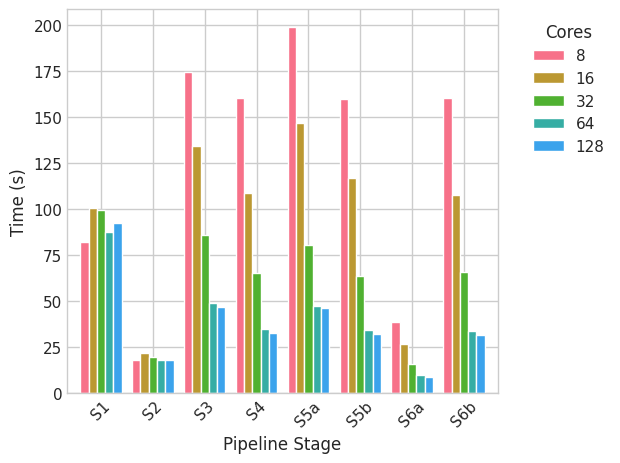

In [61]:
# ----- Plot 4: Stage-wise Execution -----
stage_cols = ['S1','S2','S3','S4','S5a','S5b','S6a','S6b']
stage_data = strong_df.groupby('TotalCores')[stage_cols].mean()
plt.figure(figsize=figsize)
stage_data.T.plot(kind='bar', width=0.8)
plt.xlabel('Pipeline Stage')
plt.ylabel('Time (s)')
# plt.title('Strong Scaling: Stage-wise Execution')
plt.xticks(rotation=45)
plt.legend(title='Cores', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(f'{output_dir}/strong_stage_times.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

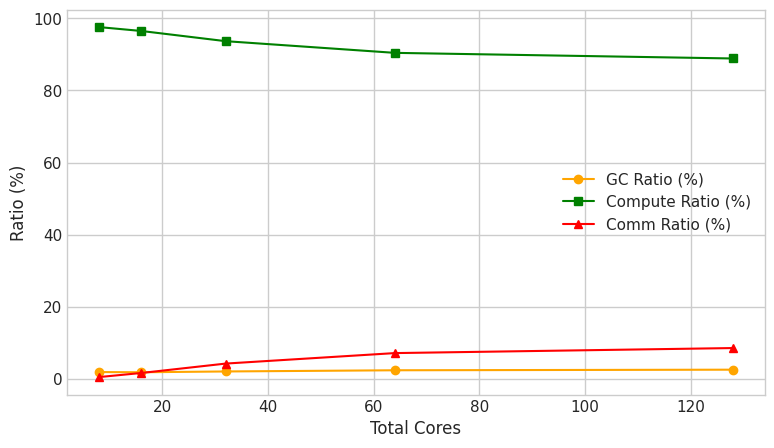

In [62]:
# ----- Plot 5: GC, Compute, Communication Ratios -----
plt.figure(figsize=figsize)
plt.plot(cores, strong_df.groupby('TotalCores')['GCRatio'].mean(), 'o-', label='GC Ratio (%)', color='orange')
plt.plot(cores, strong_df.groupby('TotalCores')['ComputeRatio'].mean(), 's-', label='Compute Ratio (%)', color='green')
plt.plot(cores, strong_df.groupby('TotalCores')['CommRatio'].mean(), '^-', label='Comm Ratio (%)', color='red')
plt.xlabel('Total Cores')
plt.ylabel('Ratio (%)')
# plt.title('Strong Scaling: GC, Compute, Communication Ratios')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/strong_ratio_metrics.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

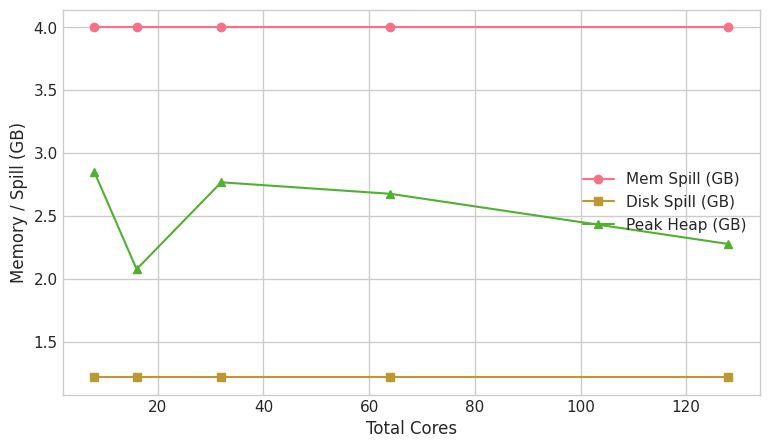

In [63]:
# ----- Plot 6: Memory & Spill -----
plt.figure(figsize=figsize)
plt.plot(cores, strong_df.groupby('TotalCores')['MemSpillGB'].mean(), 'o-', label='Mem Spill (GB)')
plt.plot(cores, strong_df.groupby('TotalCores')['DiskSpillGB'].mean(), 's-', label='Disk Spill (GB)')
plt.plot(cores, strong_df.groupby('TotalCores')['PeakHeapGB'].mean(), '^-', label='Peak Heap (GB)')
plt.xlabel('Total Cores')
plt.ylabel('Memory / Spill (GB)')
# plt.title('Strong Scaling: Memory Usage and Spill')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/strong_memory_spill.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

### 2. WEAK SCALING TABLES

In [64]:
executor_cores_cases = [2, 4]

# Select numeric columns but exclude grouping columns
numeric_cols = weak_df.select_dtypes(include=np.number).columns.tolist()
group_cols = ['TotalCores', 'Cores']
numeric_cols = [c for c in numeric_cols if c not in group_cols]

# Group and aggregate
weak_avg = weak_df.groupby(group_cols)[numeric_cols].mean().reset_index()

weak_df2 =  weak_df[weak_df['Cores'] == 2].reset_index(drop=True)
weak_df4 =  weak_df[weak_df['Cores'] == 4].reset_index(drop=True)

####  TABLE 3: Weak Scaling Comparison (2 vs 4 cores/executor)

In [65]:
# Prepare data for comparison
weak_compare = []

for cores_exec in [2, 4]:
    df_subset = weak_df[weak_df['Cores'] == cores_exec]
    summary = df_subset.groupby('TotalCores').agg({
        'AppTimeSec': 'mean',
        "DatasetSizeGB":'mean',
        'Parallelism': 'mean',
        'PeakHeapGB': 'mean',
        'MemSpillGB': 'mean',
    }).round(2)
    summary['Cores/Executor'] = cores_exec
    summary = summary.reset_index()
    weak_compare.append(summary)

weak_compare_table = pd.concat(weak_compare, ignore_index=True)
weak_compare_table = weak_compare_table[['Cores/Executor', 'TotalCores','DatasetSizeGB', 'AppTimeSec', 
                                          'Parallelism', 'PeakHeapGB', 'MemSpillGB']]

print("\n" + "="*80)
print("TABLE 3: Weak Scaling Comparison (2 vs 4 cores/executor)")
print("Directly compares the two executor configurations (2 vs 4 cores/executor) to show which performs better.")
print("="*80)
print(weak_compare_table.to_string(index=False))


TABLE 3: Weak Scaling Comparison (2 vs 4 cores/executor)
Directly compares the two executor configurations (2 vs 4 cores/executor) to show which performs better.
 Cores/Executor  TotalCores  DatasetSizeGB  AppTimeSec  Parallelism  PeakHeapGB  MemSpillGB
              2           2            3.9     1877.53         1.83        2.76        0.00
              2           4            7.8     2024.10         3.61        2.65        4.00
              2           8           15.7     2256.97         6.39        2.32        8.00
              2          12           23.4     2267.62         9.72        2.68       12.00
              2          16           31.0     2369.46        12.65        2.78       16.00
              2          32           62.2     2902.32        24.86        2.54       32.00
              4           8            3.9      727.72         5.17        2.84        1.95
              4          16            7.8      799.36        10.03        2.68        5.81
         

#### TABLE 4: Memory and Spill Analysis

In [66]:
memory_table = pd.DataFrame({
    'Configuration': [
        'Strong Scaling (Min Cores)',
        'Strong Scaling (Max Cores)',
        'Weak Scaling (2 cores/exec)',
        'Weak Scaling (4 cores/exec)'
    ],
    'PeakHeapGB': [
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].min()]['PeakHeapGB'].mean(),
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].max()]['PeakHeapGB'].mean(),
        weak_df2['PeakHeapGB'].mean(),
        weak_df4['PeakHeapGB'].mean()
    ],
    'MemSpillGB': [
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].min()]['MemSpillGB'].mean(),
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].max()]['MemSpillGB'].mean(),
        weak_df2['MemSpillGB'].mean(),
        weak_df4['MemSpillGB'].mean()
    ],
    'DiskSpillGB': [
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].min()]['DiskSpillGB'].mean(),
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].max()]['DiskSpillGB'].mean(),
        weak_df2['DiskSpillGB'].mean(),
        weak_df4['DiskSpillGB'].mean()
    ],
    'GCSec': [
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].min()]['GCSec'].mean(),
        strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].max()]['GCSec'].mean(),
        weak_df2['GCSec'].mean(),
        weak_df4['GCSec'].mean()
    ]
}).round(2)

print("\n" + "="*80)
print("TABLE 4: Memory and Spill Analysis")
print("Critical for understanding resource constraints and GC behavior.")
print("="*80)
print(memory_table.to_string(index=False))



TABLE 4: Memory and Spill Analysis
Critical for understanding resource constraints and GC behavior.
              Configuration  PeakHeapGB  MemSpillGB  DiskSpillGB  GCSec
 Strong Scaling (Min Cores)        2.85        4.00         1.22 128.11
 Strong Scaling (Max Cores)        2.28        4.00         1.22 269.18
Weak Scaling (2 cores/exec)        2.62       13.05         3.96 272.92
Weak Scaling (4 cores/exec)        2.69       11.66         3.51 506.65


#### TABLE 5: Best Configurations Comparison

In [67]:
# Strong scaling best config
strong_best_idx = strong_df['AppTimeMs'].idxmin()
strong_best = {
    'Experiment': 'Strong Scaling',
    'Executors': strong_df.loc[strong_best_idx, 'Execs'],
    'Cores/Executor': strong_df.loc[strong_best_idx, 'Cores'],
    'TotalCores': strong_df.loc[strong_best_idx, 'TotalCores'],
    'RuntimeSec': strong_df.loc[strong_best_idx, 'AppTimeSec'],
    'Efficiency%': strong_df.loc[strong_best_idx, 'Efficiency'].round(1),
    'PeakHeapGB': strong_df.loc[strong_best_idx, 'PeakHeapGB'].round(2),
    'MemSpillGB': strong_df.loc[strong_best_idx, 'MemSpillGB'].round(2)
}

# Weak scaling best config (2 cores/exec)
weak2_best_idx = weak_df2['AppTimeMs'].idxmin()
weak2_best = {
    'Experiment': 'Weak Scaling (2 cores/exec)',
    'Executors': weak_df2.loc[weak2_best_idx, 'Execs'],
    'Cores/Executor': 2,
    'TotalCores': weak_df2.loc[weak2_best_idx, 'TotalCores'],
    'RuntimeSec': weak_df2.loc[weak2_best_idx, 'AppTimeSec'],
    'Efficiency%': 'N/A',
    'PeakHeapGB': weak_df2.loc[weak2_best_idx, 'PeakHeapGB'].round(2),
    'MemSpillGB': weak_df2.loc[weak2_best_idx, 'MemSpillGB'].round(2)
}

# Weak scaling best config (4 cores/exec)
weak4_best_idx = weak_df4['AppTimeMs'].idxmin()
weak4_best = {
    'Experiment': 'Weak Scaling (4 cores/exec)',
    'Executors': weak_df4.loc[weak4_best_idx, 'Execs'],
    'Cores/Executor': 4,
    'TotalCores': weak_df4.loc[weak4_best_idx, 'TotalCores'],
    'RuntimeSec': weak_df4.loc[weak4_best_idx, 'AppTimeSec'],
    'Efficiency%': 'N/A',
    'PeakHeapGB': weak_df4.loc[weak4_best_idx, 'PeakHeapGB'].round(2),
    'MemSpillGB': weak_df4.loc[weak4_best_idx, 'MemSpillGB'].round(2)
}

best_configs_table = pd.DataFrame([strong_best, weak2_best, weak4_best])

print("="*80)
print("TABLE 5: Best Configurations Comparison")
print("Provides the optimal settings for each scenario - essential for recommendations.")
print("="*80)
print(best_configs_table.to_string(index=False))

TABLE 5: Best Configurations Comparison
Provides the optimal settings for each scenario - essential for recommendations.
                 Experiment  Executors  Cores/Executor  TotalCores  RuntimeSec Efficiency%  PeakHeapGB  MemSpillGB
             Strong Scaling         16               4          64     316.066        39.4        2.55        4.00
Weak Scaling (2 cores/exec)          1               2           2    1781.394         N/A        2.78        0.00
Weak Scaling (4 cores/exec)          2               4           8     716.885         N/A        2.82        1.95


#### TABLE 6: Parallelism and Resource Utilization

In [68]:
parallelism_table = pd.DataFrame()

# Strong scaling parallelism
strong_para = strong_df.groupby('TotalCores').agg({
    'Parallelism': 'mean',
    'Execs': 'first',
    'Cores': 'first'
}).reset_index()
strong_para['Scenario'] = 'Strong Scaling'
strong_para['Utilization%'] = (strong_para['Parallelism'] / strong_para['TotalCores'] * 100).round(1)

# Weak scaling parallelism (2 cores/exec)
weak2_para = weak_df2.groupby('TotalCores').agg({
    'Parallelism': 'mean',
    'Execs': 'first',
    'Cores': 'first'
}).reset_index()
weak2_para['Scenario'] = 'Weak Scaling (2 cores/exec)'
weak2_para['Utilization%'] = (weak2_para['Parallelism'] / weak2_para['TotalCores'] * 100).round(1)

# Weak scaling parallelism (4 cores/exec)
weak4_para = weak_df4.groupby('TotalCores').agg({
    'Parallelism': 'mean',
    'Execs': 'first',
    'Cores': 'first'
}).reset_index()
weak4_para['Scenario'] = 'Weak Scaling (4 cores/exec)'
weak4_para['Utilization%'] = (weak4_para['Parallelism'] / weak4_para['TotalCores'] * 100).round(1)

parallelism_table = pd.concat([strong_para, weak2_para, weak4_para], ignore_index=True)
parallelism_table = parallelism_table[['Scenario', 'TotalCores', 'Execs', 'Cores', 
                                        'Parallelism', 'Utilization%']]

print("="*80)
print("TABLE 6: Parallelism and Resource Utilization")
print("Shows how well Spark utilizes the available cores across all scenarios.")
print("="*80)
print(parallelism_table.to_string(index=False))

TABLE 6: Parallelism and Resource Utilization
Shows how well Spark utilizes the available cores across all scenarios.
                   Scenario  TotalCores  Execs  Cores  Parallelism  Utilization%
             Strong Scaling           8      2      4     6.657140          83.2
             Strong Scaling          16      4      4     9.731844          60.8
             Strong Scaling          32      8      4    15.216742          47.6
             Strong Scaling          64     16      4    28.413674          44.4
             Strong Scaling         128     32      4    30.805314          24.1
Weak Scaling (2 cores/exec)           2      1      2     1.834183          91.7
Weak Scaling (2 cores/exec)           4      2      2     3.609584          90.2
Weak Scaling (2 cores/exec)           8      4      2     6.393550          79.9
Weak Scaling (2 cores/exec)          12      6      2     9.721779          81.0
Weak Scaling (2 cores/exec)          16      8      2    12.647438      

### 2. WEAK SCALING PLOTS

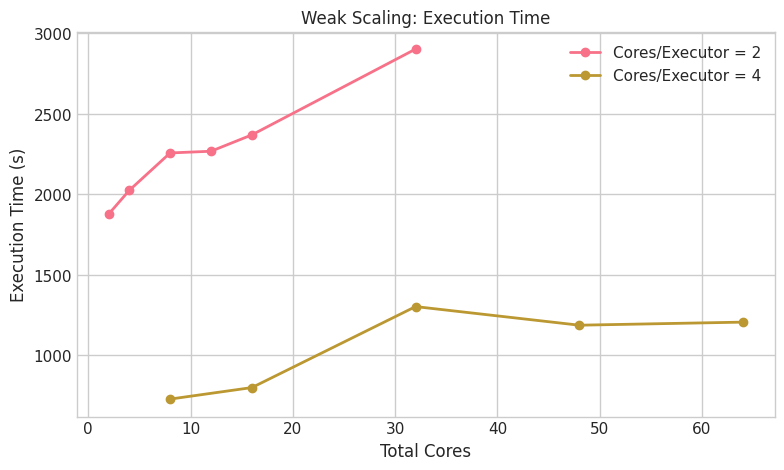

In [69]:
# ----- Plot 1: Execution Time -----
plt.figure(figsize=figsize)
for exec_cores in executor_cores_cases:
    subset = weak_avg[weak_avg['Cores'] == exec_cores]
    plt.plot(subset['TotalCores'], subset['AppTimeSec'], 'o-', linewidth=2, markersize=6,
             label=f'Cores/Executor = {exec_cores}')
plt.xlabel('Total Cores')
plt.ylabel('Execution Time (s)')
plt.title('Weak Scaling: Execution Time')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/weak_execution_time.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

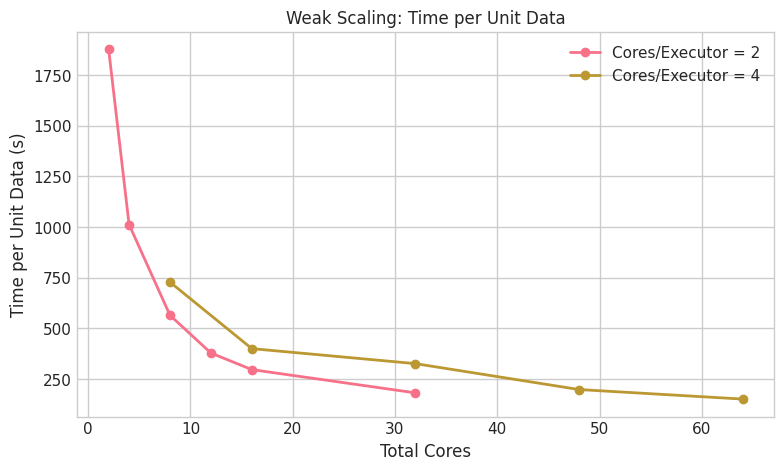

In [70]:
# ----- Plot 2: Time per Unit Data -----
plt.figure(figsize=figsize)
for exec_cores in executor_cores_cases:
    subset = weak_avg[weak_avg['Cores'] == exec_cores]
    plt.plot(subset['TotalCores'], subset['TimePerUnit'], 'o-', linewidth=2, markersize=6,
             label=f'Cores/Executor = {exec_cores}')
plt.xlabel('Total Cores')
plt.ylabel('Time per Unit Data (s)')
plt.title('Weak Scaling: Time per Unit Data')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/weak_time_per_unit.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

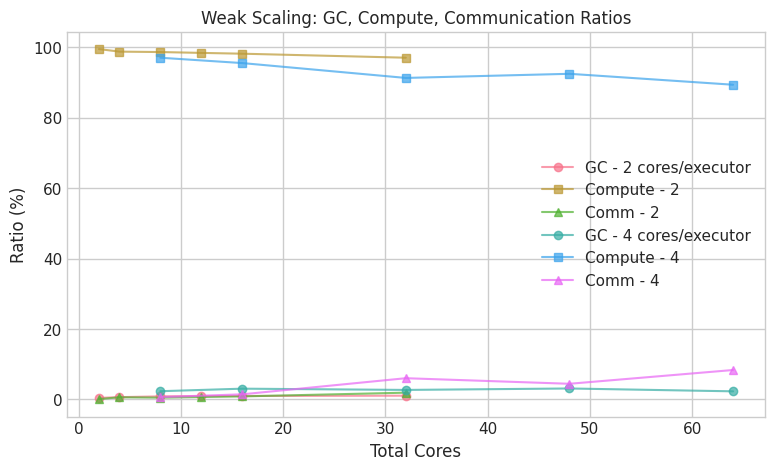

In [71]:
# ----- Plot 3: GC, Compute, Communication Ratios -----
plt.figure(figsize=figsize)
for exec_cores in executor_cores_cases:
    subset = weak_avg[weak_avg['Cores'] == exec_cores]
    gc_ratio = 100*subset['GCSec']/subset['ExecRunTimeSec']
    compute_ratio = 100*subset['ComputeSec']/subset['ExecRunTimeSec']
    comm_ratio = 100*subset['CommSec']/subset['ExecRunTimeSec']
    plt.plot(subset['TotalCores'], gc_ratio, 'o-', label=f'GC - {exec_cores} cores/executor', alpha=0.7)
    plt.plot(subset['TotalCores'], compute_ratio, 's-', label=f'Compute - {exec_cores}', alpha=0.7)
    plt.plot(subset['TotalCores'], comm_ratio, '^-', label=f'Comm - {exec_cores}', alpha=0.7)
plt.xlabel('Total Cores')
plt.ylabel('Ratio (%)')
plt.title('Weak Scaling: GC, Compute, Communication Ratios')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/weak_ratio_metrics.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

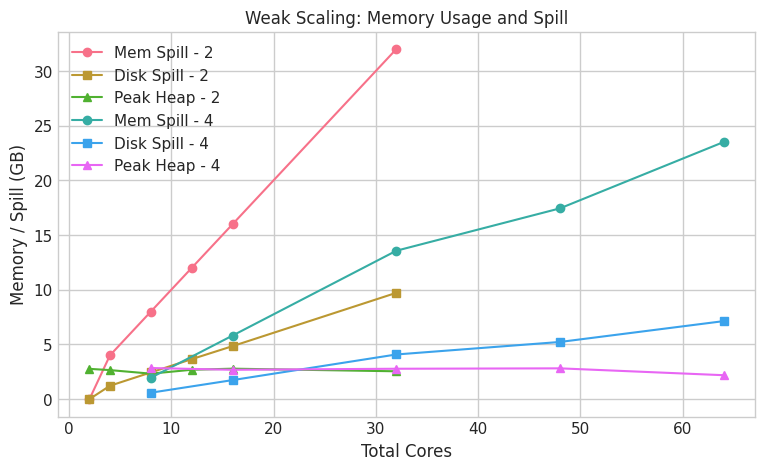

In [72]:
# ----- Plot 4: Memory & Spill -----
plt.figure(figsize=figsize)
for exec_cores in executor_cores_cases:
    subset = weak_avg[weak_avg['Cores'] == exec_cores]
    plt.plot(subset['TotalCores'], subset['MemSpillGB'], 'o-', label=f'Mem Spill - {exec_cores}')
    plt.plot(subset['TotalCores'], subset['DiskSpillGB'], 's-', label=f'Disk Spill - {exec_cores}')
    plt.plot(subset['TotalCores'], subset['PeakHeapGB'], '^-', label=f'Peak Heap - {exec_cores}')
plt.xlabel('Total Cores')
plt.ylabel('Memory / Spill (GB)')
plt.title('Weak Scaling: Memory Usage and Spill')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/weak_memory_spill.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

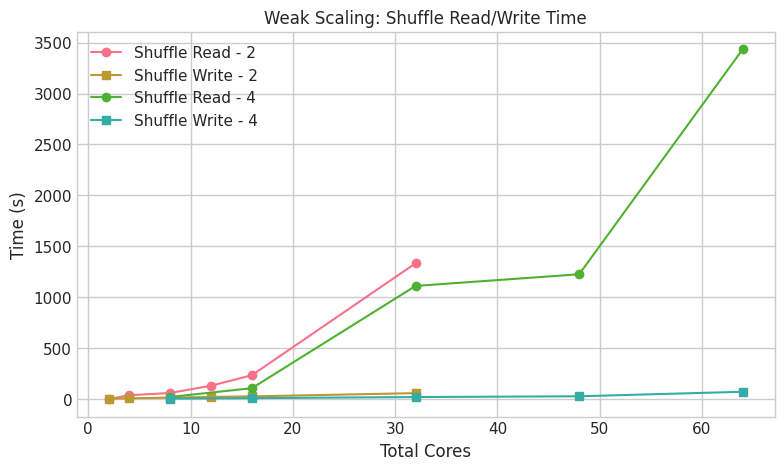

In [73]:
# ----- Plot 5: Shuffle Read/Write -----
plt.figure(figsize=figsize)
for exec_cores in executor_cores_cases:
    subset = weak_avg[weak_avg['Cores'] == exec_cores]
    plt.plot(subset['TotalCores'], subset['ShuffleReadSec'], 'o-', label=f'Shuffle Read - {exec_cores}')
    plt.plot(subset['TotalCores'], subset['ShuffleWriteSec'], 's-', label=f'Shuffle Write - {exec_cores}')
plt.xlabel('Total Cores')
plt.ylabel('Time (s)')
plt.title('Weak Scaling: Shuffle Read/Write Time')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/weak_shuffle_times.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

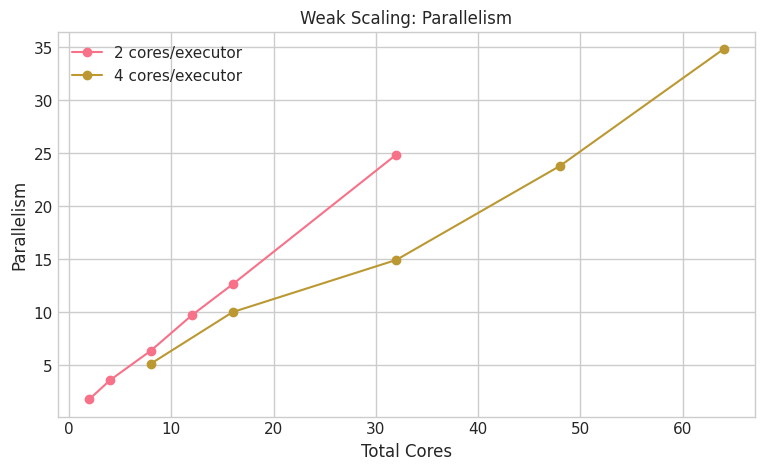

In [74]:
# ----- Plot 6: Parallelism -----
plt.figure(figsize=figsize)
for exec_cores in executor_cores_cases:
    subset = weak_avg[weak_avg['Cores'] == exec_cores]
    plt.plot(subset['TotalCores'], subset['Parallelism'], 'o-', label=f'{exec_cores} cores/executor')
plt.xlabel('Total Cores')
plt.ylabel('Parallelism')
plt.title('Weak Scaling: Parallelism')
plt.grid(True)
plt.legend()
plt.savefig(f'{output_dir}/weak_parallelism.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 900x500 with 0 Axes>

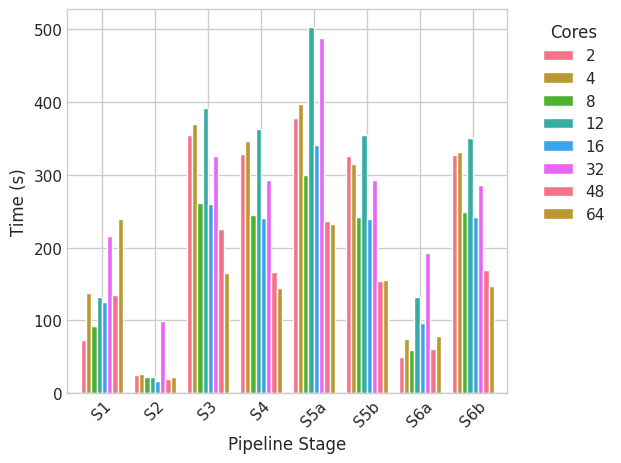

In [75]:
# ----- Plot 7: Stage-wise Execution -----
stage_cols = ['S1','S2','S3','S4','S5a','S5b','S6a','S6b']
stage_data = weak_df.groupby('TotalCores')[stage_cols].mean()
plt.figure(figsize=figsize)
stage_data.T.plot(kind='bar', width=0.8)
plt.xlabel('Pipeline Stage')
plt.ylabel('Time (s)')
# plt.title('Weak Scaling: Stage-wise Execution')
plt.xticks(rotation=45)
plt.legend(title='Cores', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(f'{output_dir}/weak_stage_times.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

### 3. MEMORY AND RESOURCE ANALYSIS PLOTS

In [76]:
mem_df = df[df['Type']=='MemoryStudy']
mem_df

,Type,Execs,Cores,TotalCores,MemGB,Data,S1,S2,S3,S4,...,ShuffleReadSec,ShuffleWriteSec,CommSec,ComputeSec,MemSpillGB,DiskSpillGB,PeakHeapGB,TimePerCore,SizeFactor,TimePerUnit
48,MemoryStudy,16,2,32,4,small_8,164.190334,20.133831,252.548677,220.270893,...,956.913,30.213832,987.126832,31121.788168,23.250,7.019094,2.842694,48.443375,8.0,193.773500
49,MemoryStudy,16,2,32,4,small_8,174.208239,20.658818,244.928850,219.703930,...,1113.779,30.338500,1144.117500,31981.759500,23.250,7.019094,2.641517,49.722781,8.0,198.891125
50,MemoryStudy,16,2,32,4,small_8,174.472428,18.923709,247.388094,221.427256,...,952.718,30.260377,982.978377,31661.303623,23.250,7.019094,2.849626,49.124750,8.0,196.499000
51,MemoryStudy,16,2,32,6,small_8,149.392480,18.426589,234.224859,228.250891,...,546.745,43.533050,590.278050,32711.843950,24.000,7.277374,2.872226,49.979312,8.0,199.917250
52,MemoryStudy,16,2,32,6,small_8,118.784608,19.465980,281.421542,226.152082,...,671.909,52.288848,724.197848,36039.796152,24.000,7.277374,2.591222,53.923281,8.0,215.693125
53,MemoryStudy,16,2,32,8,small_8,245.644087,31.828593,297.271733,284.162451,...,1223.337,46.928695,1270.265695,36468.598305,16.000,4.844468,2.601399,63.573500,8.0,254.294000
54,MemoryStudy,16,2,32,8,small_8,508.185614,28.880897,424.329802,303.322328,...,1752.167,59.800338,1811.967338,38466.626662,24.375,7.393090,2.625838,74.877000,8.0,299.508000
55,MemoryStudy,16,2,32,8,small_8,129.542327,21.631673,300.425039,270.834323,...,468.790,36.623439,505.413439,35617.307561,16.000,4.844468,2.696302,56.638750,8.0,226.555000
56,MemoryStudy,16,2,32,10,small_8,174.779746,20.673021,260.947432,254.668412,...,965.088,35.498898,1000.586898,35931.664102,20.500,6.206889,2.410686,60.672219,8.0,242.688875


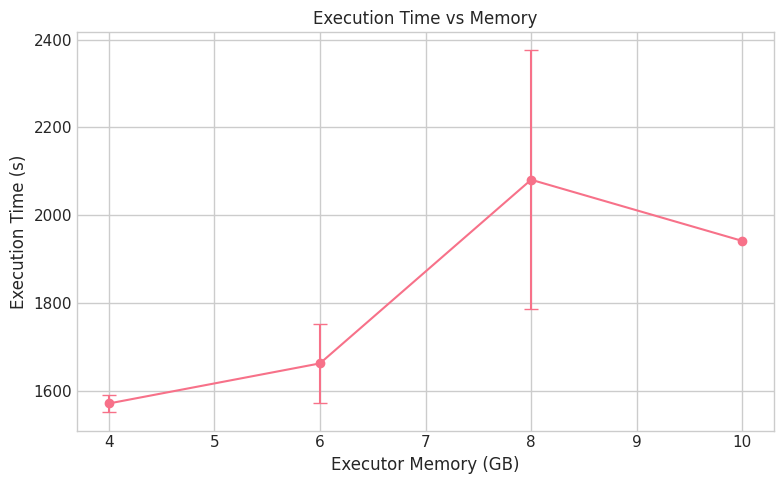

In [81]:
## 1. Execution Time vs Memory (Primary Result)
# Shows whether increasing memory actually improves performance.
# Data size considered : data_8 : 31GB

times = mem_df.groupby('MemGB')['AppTimeSec'].mean()
std = mem_df.groupby('MemGB')['AppTimeSec'].std()

plt.figure(figsize=(8,5))
plt.errorbar(times.index, times, yerr=std, marker='o', capsize=5)
plt.xlabel("Executor Memory (GB)")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Memory")
plt.tight_layout()
plt.savefig(f'{output_dir}/mem_time_mem.png', dpi=dpi, bbox_inches='tight')
plt.grid(True)
plt.show()
plt.close()

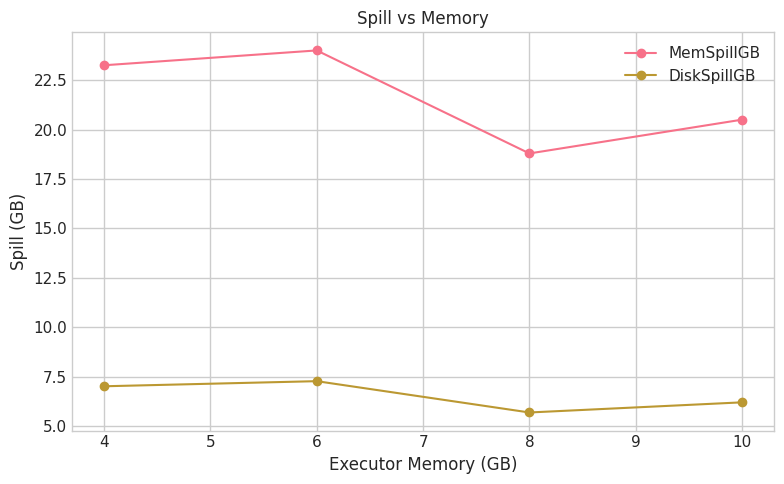

In [78]:
# Memory Spill vs Memory

spill = mem_df.groupby('MemGB')[['MemSpillGB','DiskSpillGB']].mean()

spill.plot(marker='o', figsize=(8,5))
plt.xlabel("Executor Memory (GB)")
plt.ylabel("Spill (GB)")
plt.title("Spill vs Memory")
plt.tight_layout()
plt.savefig(f'{output_dir}/mem_splill_mem.png', dpi=dpi, bbox_inches='tight')
plt.grid(True)
plt.show()
plt.close()

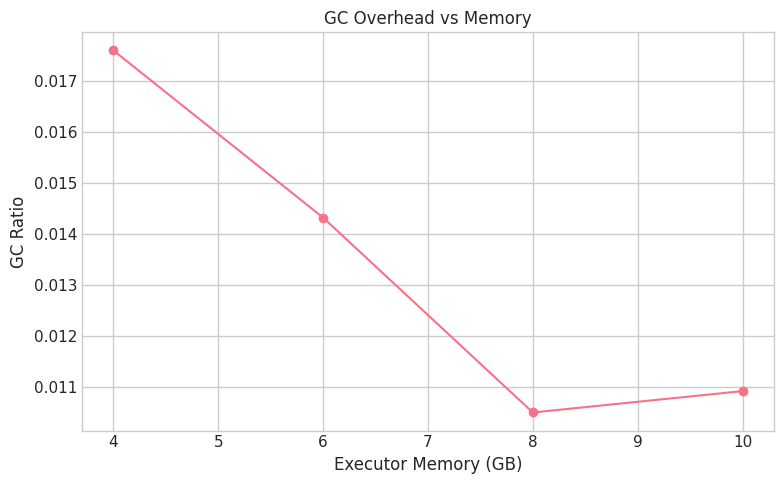

In [79]:
# GC Overhead vs Memory

gc = mem_df.groupby('MemGB')['GCRatio'].mean()

plt.figure(figsize=(8,5))
plt.plot(gc.index, gc, marker='o')
plt.xlabel("Executor Memory (GB)")
plt.ylabel("GC Ratio")
plt.title("GC Overhead vs Memory")
plt.tight_layout()
plt.savefig(f'{output_dir}/mem_gc_mem.png', dpi=dpi, bbox_inches='tight')
plt.grid(True)
plt.show()
plt.close()

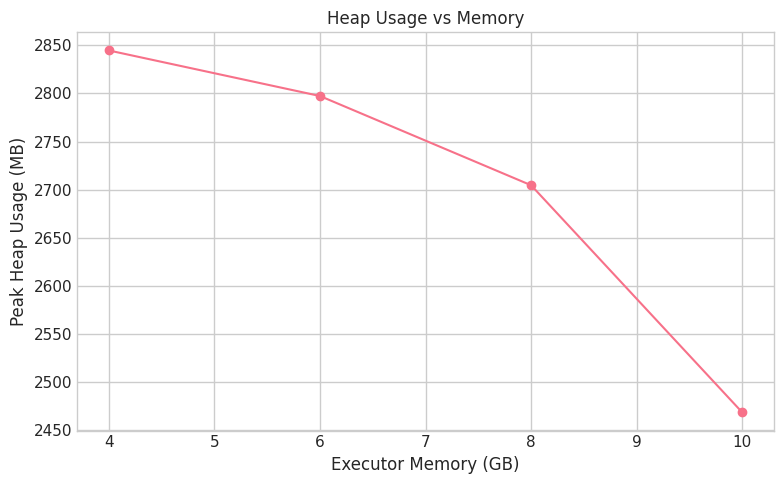

In [80]:
# Peak Heap Usage vs Memory
heap = mem_df.groupby('MemGB')['PeakHeapMB'].mean()

plt.figure(figsize=(8,5))
plt.plot(heap.index, heap, marker='o')
plt.xlabel("Executor Memory (GB)")
plt.ylabel("Peak Heap Usage (MB)")
plt.title("Heap Usage vs Memory")
plt.tight_layout()
plt.savefig(f'{output_dir}/mem_peakheap_mem.png', dpi=dpi, bbox_inches='tight')
plt.grid(True)
plt.show()
plt.close()

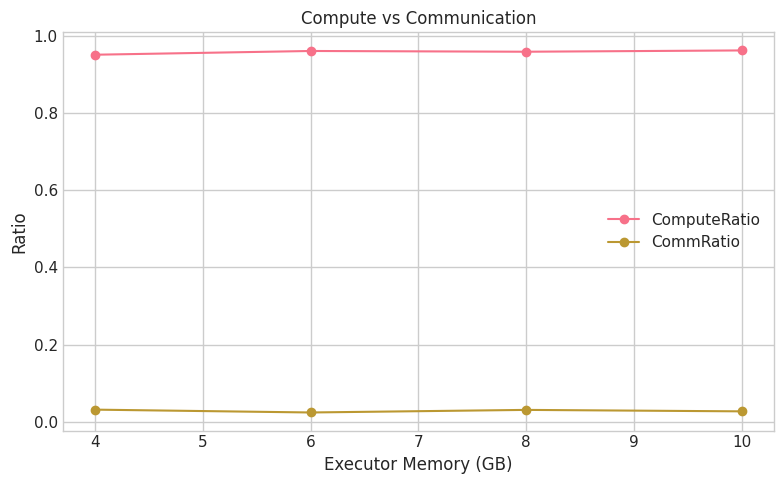

In [36]:
# Compute vs Communication Ratio

ratio = mem_df.groupby('MemGB')[['ComputeRatio','CommRatio']].mean()

ratio.plot(marker='o', figsize=(8,5))
plt.xlabel("Executor Memory (GB)")
plt.ylabel("Ratio")
plt.title("Compute vs Communication")
plt.tight_layout()
plt.savefig(f'{output_dir}/mem_compute_comm_mem.png', dpi=dpi, bbox_inches='tight')
plt.grid(True)
plt.show()
plt.close()

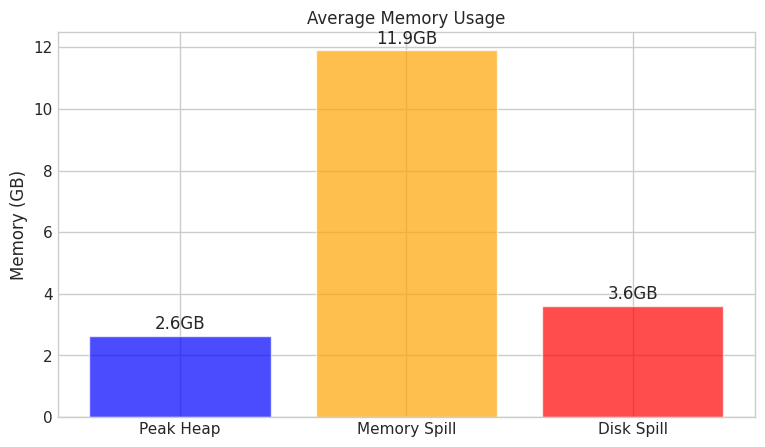

In [37]:
# ----- Plot 1: Average Memory Components -----
plt.figure(figsize=figsize)
mem_components = ['PeakHeapGB', 'MemSpillGB', 'DiskSpillGB']
mem_avg = df[mem_components].mean() 

bars = plt.bar(['Peak Heap', 'Memory Spill', 'Disk Spill'], 
               mem_avg.values, color=['blue', 'orange', 'red'], alpha=0.7)
plt.ylabel('Memory (GB)')
plt.title('Average Memory Usage')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}GB', ha='center', va='bottom')

plt.savefig(f'{output_dir}/memory_avg_components.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

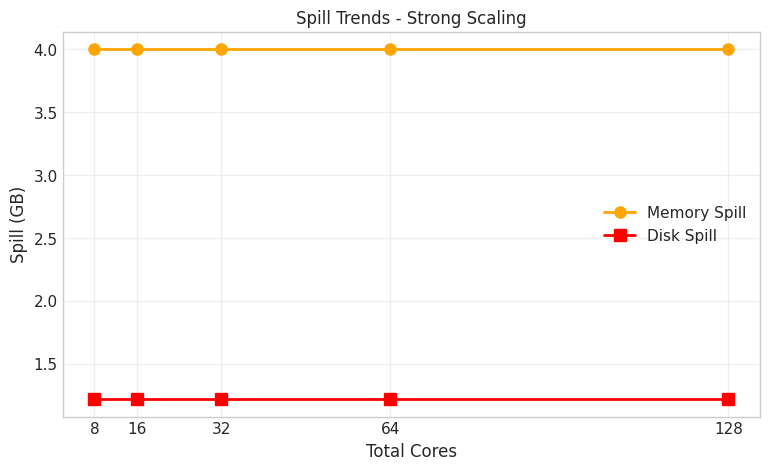

In [38]:
# ----- Plot 2: Memory Spill vs Total Cores (Strong Scaling) -----
plt.figure(figsize=figsize)
mem_strong = strong_df.groupby('TotalCores')[['MemSpillGB', 'DiskSpillGB']].mean() 

plt.plot(mem_strong.index, mem_strong['MemSpillGB'], 'o-', linewidth=2, markersize=8, 
         label='Memory Spill', color='orange')
plt.plot(mem_strong.index, mem_strong['DiskSpillGB'], 's-', linewidth=2, markersize=8, 
         label='Disk Spill', color='red')

plt.xlabel('Total Cores')
plt.ylabel('Spill (GB)')
plt.title('Spill Trends - Strong Scaling')
plt.xticks(mem_strong.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{output_dir}/memory_spill_strong.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

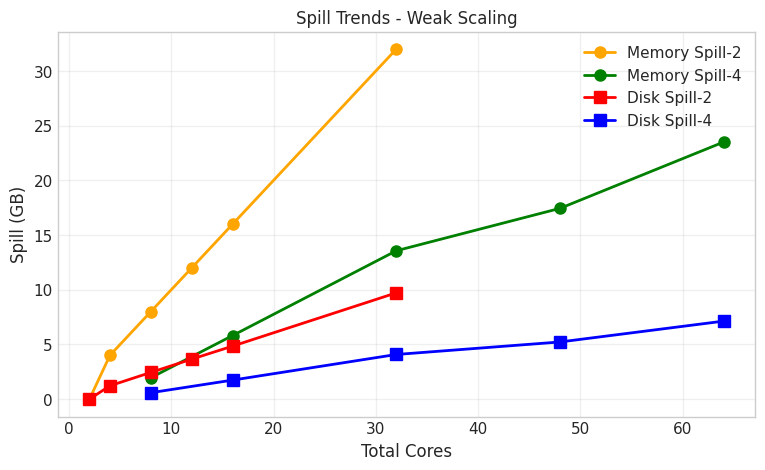

In [39]:
# ----- Plot 2: Memory Spill vs Total Cores (Weak Scaling) -----
plt.figure(figsize=figsize)
mem_weak2 = weak_df2.groupby('TotalCores')[['MemSpillGB', 'DiskSpillGB']].mean() 
mem_weak4 = weak_df4.groupby('TotalCores')[['MemSpillGB', 'DiskSpillGB']].mean() 

plt.plot(mem_weak2.index, mem_weak2['MemSpillGB'], 'o-', linewidth=2, markersize=8, 
         label='Memory Spill-2', color='orange')
plt.plot(mem_weak4.index, mem_weak4['MemSpillGB'], 'o-', linewidth=2, markersize=8, 
         label='Memory Spill-4', color='green')
plt.plot(mem_weak2.index, mem_weak2['DiskSpillGB'], 's-', linewidth=2, markersize=8, 
         label='Disk Spill-2', color='red')
plt.plot(mem_weak4.index, mem_weak4['DiskSpillGB'], 's-', linewidth=2, markersize=8, 
         label='Disk Spill-4', color='blue')

plt.xlabel('Total Cores')
plt.ylabel('Spill (GB)')
plt.title('Spill Trends - Weak Scaling')
# plt.xticks(mem_weak.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{output_dir}/memory_spill_weak.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

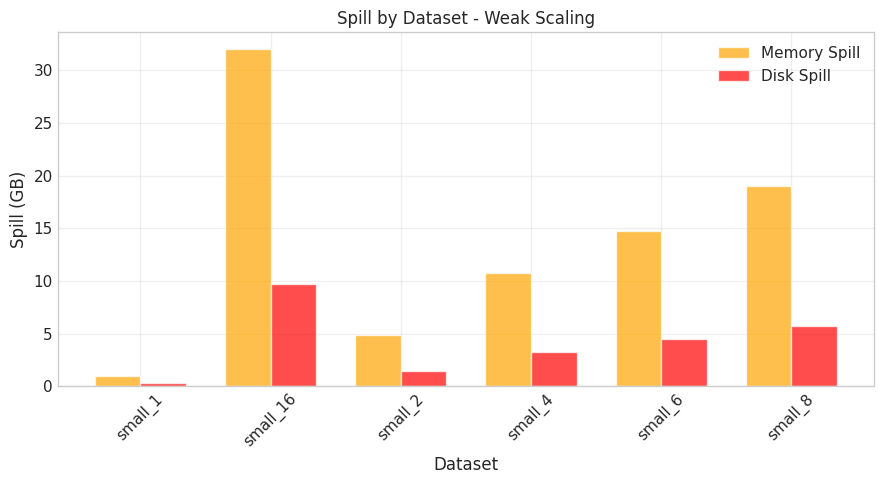

In [40]:
# ----- Plot 3: Memory Spill vs Dataset (Weak Scaling) -----
plt.figure(figsize=figsize)
mem_weak = weak_df.groupby('Data')[['MemSpillGB', 'DiskSpillGB']].mean()

x = range(len(mem_weak.index))
width = 0.35

plt.bar([i - width/2 for i in x], mem_weak['MemSpillGB'], width, 
        label='Memory Spill', color='orange', alpha=0.7)
plt.bar([i + width/2 for i in x], mem_weak['DiskSpillGB'], width, 
        label='Disk Spill', color='red', alpha=0.7)

plt.xlabel('Dataset')
plt.ylabel('Spill (GB)')
plt.title('Spill by Dataset - Weak Scaling')
plt.xticks(x, mem_weak.index, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/memory_spill_weak_by_dataset.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

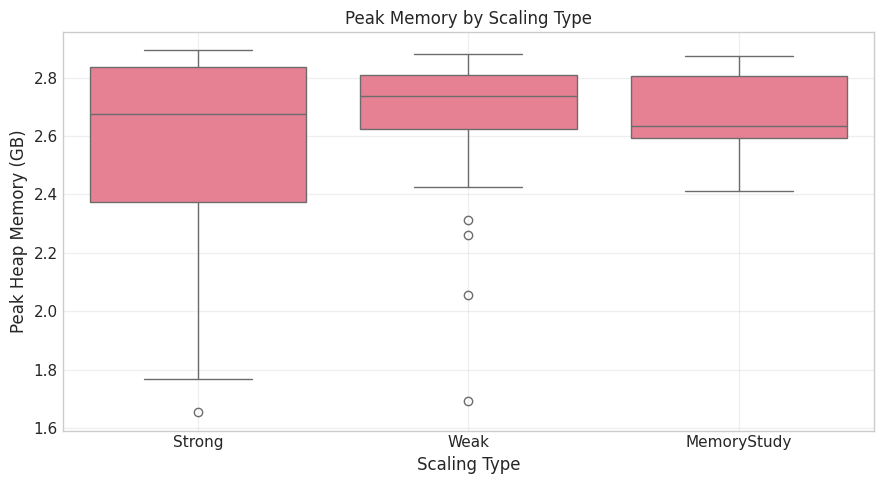

In [41]:
# ----- Plot 4: Peak Heap Memory Distribution -----
plt.figure(figsize=figsize)
sns.boxplot(data=df,x="Type",y="PeakHeapGB")
plt.ylabel("Peak Heap Memory (GB)")
plt.xlabel("Scaling Type")
plt.title("Peak Memory by Scaling Type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/memory_peak_by_type.png", dpi=dpi, bbox_inches="tight")
plt.show()
plt.close()

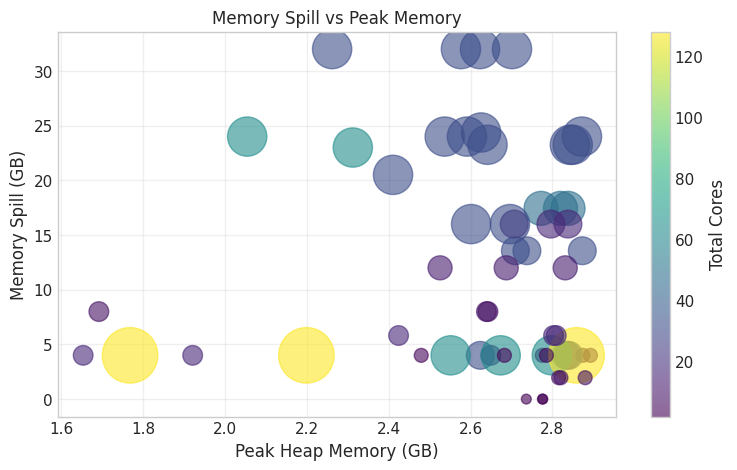

In [42]:
# ----- Plot 5: Memory Spill vs Peak Memory -----
plt.figure(figsize=figsize)
scatter = plt.scatter(df['PeakHeapGB'], df['MemSpillGB'], 
                      c=df['TotalCores'], s=df['Execs']*50, alpha=0.6, cmap='viridis')
plt.xlabel('Peak Heap Memory (GB)')
plt.ylabel('Memory Spill (GB)')
plt.title('Memory Spill vs Peak Memory')
plt.colorbar(scatter, label='Total Cores')
plt.grid(True, alpha=0.3)
plt.savefig(f'{output_dir}/memory_spill_vs_peak.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

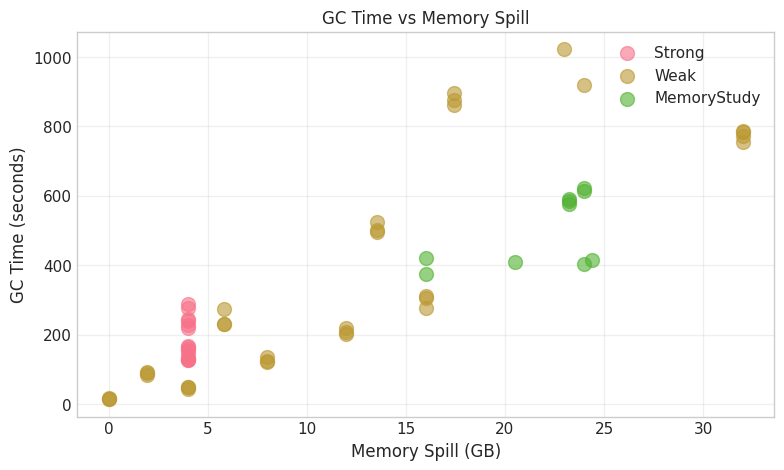

In [43]:
# ----- Plot 6: GC Time vs Memory Spill -----
plt.figure(figsize=figsize)
for scaling_type in df['Type'].unique():
    subset = df[df['Type'] == scaling_type]
    plt.scatter(subset['MemSpillGB'], subset['GCSec'], s=100, alpha=0.6, label=scaling_type)

plt.xlabel('Memory Spill (GB)')
plt.ylabel('GC Time (seconds)')
plt.title('GC Time vs Memory Spill')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{output_dir}/gc_time_vs_spill.png', dpi=dpi, bbox_inches='tight')
plt.show()
plt.close()

### 4. SUMMARY STATISTICS TABLE

In [44]:
# Create a summary table
summary_data = {
    'Metric': [
        'Total Experiments', 'Strong Scaling Runs', 'Weak Scaling Runs',
        'Avg Execution Time (s)', 'Min Execution Time (s)', 'Max Execution Time (s)',
        'Avg GC Time (s)', 'Avg GC Ratio (%)', 'Avg Compute Ratio (%)', 'Avg Comm Ratio (%)',
        'Avg Peak Heap (GB)', 'Total Memory Spill (GB)', 'Total Disk Spill (GB)',
        'Best Configuration (Execs×Cores)', 'Best Time (s)',
        'Most Efficient Config', 'Time per Core (ms/core)'
    ],
    'Value': [
        f'{len(df)}', f'{len(strong_df)}', f'{len(weak_df)}',
        f'{df["AppTimeSec"].mean():.2f}', f'{df["AppTimeSec"].min():.2f}', f'{df["AppTimeSec"].max():.2f}',
        f'{df["GCSec"].mean():.2f}', f'{df["GCRatio"].mean()*100:.2f}', f'{df["ComputeRatio"].mean():.2f}', f'{df["CommRatio"].mean()*100:.2f}',
        f'{df["PeakHeapMB"].mean():.2f}', f'{df["MemSpillGB"].sum():.2f}', f'{df["DiskSpillGB"].sum():.2f}',
        f'{df.loc[df["AppTimeSec"].idxmin(), "Execs"]}×{df.loc[df["AppTimeSec"].idxmin(), "Cores"]}',
        f'{df.loc[df["AppTimeSec"].idxmin(), "AppTimeSec"]:.2f}',
        f'{df.loc[df["TimePerCore"].idxmin(), "Execs"]}×{df.loc[df["TimePerCore"].idxmin(), "Cores"]}',
        f'{df["TimePerCore"].min():.2f}'
    ]
}

summary_df = pd.DataFrame(summary_data)

summary_df

,Metric,Value
0,Total Experiments,58
1,Strong Scaling Runs,15
2,Weak Scaling Runs,33
3,Avg Execution Time (s),1477.15
4,Min Execution Time (s),316.07
5,Max Execution Time (s),3021.64
6,Avg GC Time (s),346.20
7,Avg GC Ratio (%),1.74
8,Avg Compute Ratio (%),0.95
9,Avg Comm Ratio (%),2.85


#### Save all tables to CSV for report

In [45]:
import os
os.makedirs('report_tables', exist_ok=True)

strong_perf_table.to_csv('report_tables/table1_strong_performance.csv', index=False)
strong_time_table.to_csv('report_tables/table2_strong_breakdown.csv', index=False)
weak_compare_table.to_csv('report_tables/table3_weak_comparison.csv', index=False)
memory_table.to_csv('report_tables/table4_memory_analysis.csv', index=False)
best_configs_table.to_csv('report_tables/table5_best_configs.csv', index=False)
parallelism_table.to_csv('report_tables/table6_parallelism.csv', index=False)

print("="*80)
print("All tables saved to 'report_tables/' directory")
print("="*80)

All tables saved to 'report_tables/' directory


#### 5. BEST CONFIGURATIONS 

In [48]:
best_time = df.loc[df['AppTimeSec'].idxmin()]
best_efficient = df.loc[df['TimePerCore'].idxmin()]
best_weak = weak_df.loc[weak_df['TimePerUnit'].idxmin()]

print("="*60)
print("BEST PERFORMANCE CONFIGURATION")
print("="*60)
print(f"Strong Scaling - Best Time: {best_time['Execs']} executors × {best_time['Cores']} cores = {best_time['TotalCores']} cores")
print(f"Execution Time: {best_time['AppTimeSec']:.2f} s, Data: {best_time['Data']}")

print("\n" + "="*60)
print("MOST EFFICIENT CONFIGURATION (Time per Core)")
print("="*60)
print(f"{best_efficient['Execs']} executors x {best_efficient['Cores']} cores = {best_efficient['TotalCores']} cores")
print(f"Time per Core: {best_efficient['TimePerCore']:.2f} s/core")

print("\n" + "="*60)
print("MOST EFFICIENT WEAK SCALING CONFIGURATION (Time per Unit Data)")
print("="*60)
print(f"{best_weak['Execs']} executors x {best_weak['Cores']} cores = {best_weak['TotalCores']} cores")
print(f"Time per Unit Data: {best_weak['TimePerUnit']:.2f} s/unit")

BEST PERFORMANCE CONFIGURATION
Strong Scaling - Best Time: 16 executors × 4 cores = 64 cores
Execution Time: 316.07 s, Data: small_2

MOST EFFICIENT CONFIGURATION (Time per Core)
32 executors x 4 cores = 128 cores
Time per Core: 2.57 s/core

MOST EFFICIENT WEAK SCALING CONFIGURATION (Time per Unit Data)
16 executors x 4 cores = 64 cores
Time per Unit Data: 147.82 s/unit
